In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, windows
from scipy.stats import norm
import pandas as pd
import glob

data = []
for file in glob.glob("./LightYieldCs137/*.dat"):
    df = pd.read_csv(file, delimiter = "\t", names = ["ch","counts"], index_col=False)
    data.append(df)

C:\Users\decla\AppData\Local\Temp\ipykernel_7052\3626034183.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("copper")  # or 'plasma', 'coolwarm', etc.


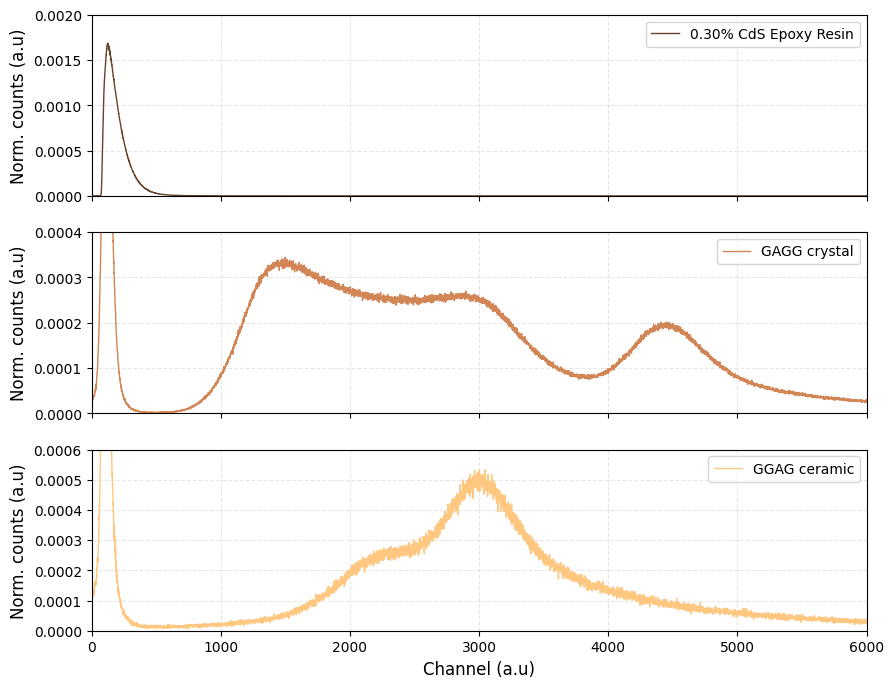

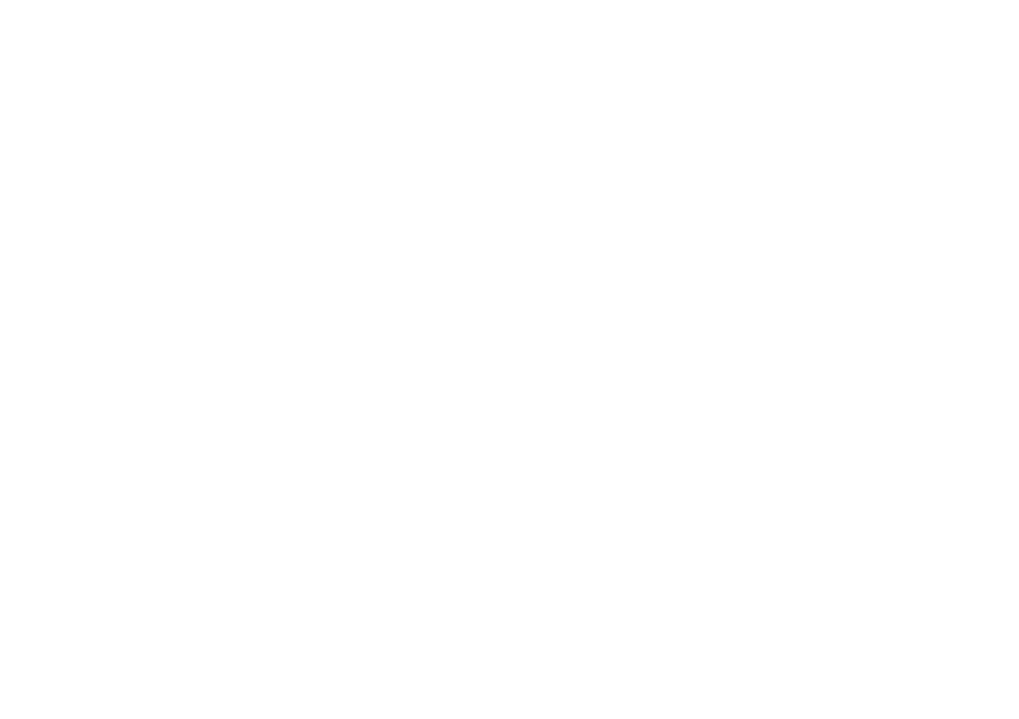

In [3]:
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from plot_utils import set_plot_style

set_plot_style("copper")
cds = data[0]
gagg = data[1]
ggag_a = data[2]
ggag_s = data[3]

num_lines = 4
cmap = get_cmap("copper")  # or 'plasma', 'coolwarm', etc.
norm = Normalize(vmin=0, vmax=num_lines-1)

plt.figure(figsize = (10,7))
fig, axes = plt.subplots(3,1,figsize = (10,8), sharex = True)

axes[0].plot(cds["ch"][:-1]/4,cds["counts"][:-1]/sum(cds["counts"][:-1]), label = "0.30% CdS Epoxy Resin", lw = 1, alpha = 1, color = cmap(norm(1)))
axes[1].plot(gagg["ch"][:-1],gagg["counts"][:-1]/sum(gagg["counts"][:-1]), label = "GAGG crystal", lw = 1, alpha = 1, color = cmap(norm(2)))
axes[2].plot(ggag_a["ch"][:-1],ggag_a["counts"][:-1]/sum(ggag_a["counts"][:-1]), label = "GGAG ceramic", lw = 1, alpha = 1, color = cmap(norm(3)))
# axes[3].plot(ggag_s["ch"][:-1],ggag_s["counts"][:-1]/sum(ggag_s["counts"][:-1]), label = "GGAG Source beside", lw = 1, alpha = 0.5)

ylims = [0.002,0.0004, 0.0006]
for i,ax in enumerate(axes):
    # ax.set_yscale("log")
    ax.set_xlim(0,6000)
    ax.set_ylim(0,ylims[i])
    ax.legend()
    ax.set_ylabel("Norm. counts (a.u)")

# plt.ylim(1e-6,6e-3)
# plt.xlim(0,6000)
plt.xlabel("Channel (a.u)")
plt.show()

In [14]:
tds = [2.41,149]
ms = [0.83, 0.17]

Teff = 0
for t,m in zip(tds,ms):
    Teff+=m/t
teff = 1/Teff
print(teff)

2.8940269842689825


In [ ]:
def capacitance(t, V, R):
    return 